In [1]:
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from transformers import pipeline
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

from datasets import Dataset
import torch
from sklearn.manifold import TSNE

c:\Users\mario\Desktop\NLP\FinSent\env_nlp\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
aggresive = False

if aggresive:
    csv_path = "../data/topic/topics_aggressive.csv"
else:
    csv_path = "../data/topic/topics_light.csv"

df = pd.read_csv(csv_path)

In [3]:
y = df["label"].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # 'neutral', 'positive', 'negative'

print(y[:5])
print(y.dtype)

print("\n",y_encoded[:5])
print(y_encoded.dtype)

['neutral' 'neutral' 'negative' 'positive' 'positive']
object

 [1 1 0 2 2]
int32


In [4]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df["text"],
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

# Split del train in train e validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

train_df = pd.DataFrame({"text": X_train_final, "label": y_train_final})
val_df = pd.DataFrame({"text": X_val, "label": y_val})
test_df = pd.DataFrame({"text": X_test_raw, "label": y_test})

In [5]:
def evaluate_model_hf(y_true_labels, y_pred_labels, split_name="Test"):
    """
    Valuta le performance di un modello Hugging Face su un dataset e stampa le metriche + matrice di confusione.
    """
    print(f"\n--- {split_name} Results ---")
    print(classification_report(y_true_labels, y_pred_labels, digits=4))

    # === METRICHE GLOBALI ===
    acc = accuracy_score(y_true_labels, y_pred_labels)
    precision = precision_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)
    recall = recall_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)
    f1 = f1_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    # === CONFUSION MATRIX ===
    unique_labels = sorted(set(y_true_labels) | set(y_pred_labels))  # Unione di predetti e reali
    cm = confusion_matrix(y_true_labels, y_pred_labels, labels=unique_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{split_name} Confusion Matrix")
    plt.show()

## Inferenza Diretta, senza fine-tuning e allenamento

In [6]:
device = 0 if torch.cuda.is_available() else -1
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA GeForce RTX 2060


In [6]:
def evaluate_hf_model(test_texts, model_name="yiyanghkust/finbert-tone"):
    """
    Esegue inferenza su un test set con un modello HF pre-addestrato e calcola le metriche.
    """
    # 1. Crea pipeline di sentiment analysis
    hf_pipeline = pipeline(
        "sentiment-analysis",
        model=model_name,
        device=device,
        batch_size=16
    )

    # 2. Esegui inferenza
    predictions = hf_pipeline(test_texts.tolist(), truncation=True)

    # 3. Estrai etichette predette
    y_pred = [pred["label"].lower() for pred in predictions]  # es. "POSITIVE" → "positive"

    #evaluate_model_hf(y_test, y_pred, split_name="Test")

    return y_pred


In [7]:
def evaluate_multiple_hf_models(model_names, X_test_raw, y_test):
    """
    Esegue inferenza e valutazione su più modelli Hugging Face e salva le metriche in un DataFrame/CSV.
    
    :param model_names: lista di modelli Hugging Face (str)
    :param X_test_raw: lista o pandas Series di testi grezzi
    :param y_test: lista o Series delle label vere
    :param save_csv_path: se specificato, salva il CSV con i risultati
    :return: DataFrame con metriche
    """
    results = []

    for model_name in model_names:
        try:
            print(f"\n➡️  Eseguendo inferenza con: {model_name}")
            y_pred = evaluate_hf_model(X_test_raw, model_name=model_name)

            acc = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
            recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
            f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

            results.append({
                "model": model_name,
                "accuracy": acc,
                "precision": precision,
                "recall": recall,
                "f1_score": f1
            })
        except Exception as e:
            print(f"❌ Errore con il modello: {model_name}")
            print(f"   {type(e).__name__}: {e}")

    df_results = pd.DataFrame(results)

    return df_results


In [71]:
hf_models = [
    "mrm8488/deberta-v3-ft-financial-news-sentiment-analysis",
    "mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis",
    "soleimanian/financial-roberta-large-sentiment",
    "yiyanghkust/finbert-tone",
    "ProsusAI/finbert"
]

hf_results_df = evaluate_multiple_hf_models(hf_models, X_test_raw, y_test)


➡️  Eseguendo inferenza con: mrm8488/deberta-v3-ft-financial-news-sentiment-analysis


Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



➡️  Eseguendo inferenza con: mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis


Device set to use cuda:0



➡️  Eseguendo inferenza con: soleimanian/financial-roberta-large-sentiment


Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



➡️  Eseguendo inferenza con: yiyanghkust/finbert-tone


Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



➡️  Eseguendo inferenza con: ProsusAI/finbert


Device set to use cuda:0


In [72]:
pd.set_option('display.width', 1000)

sorted_results = hf_results_df.sort_values(by="accuracy", ascending=False).reset_index(drop=True)
print(sorted_results)

                                               model  accuracy  precision    recall  f1_score
0  mrm8488/deberta-v3-ft-financial-news-sentiment...  0.989680   0.989450  0.989450  0.989450
1                                   ProsusAI/finbert  0.882353   0.851867  0.907860  0.875420
2  mrm8488/distilroberta-finetuned-financial-news...  0.853457   0.844990  0.835670  0.840134
3                           yiyanghkust/finbert-tone  0.786378   0.792026  0.723432  0.743643
4      soleimanian/financial-roberta-large-sentiment  0.780186   0.785462  0.846567  0.792854


In [88]:
results_folder = "../training_results/"

if aggresive:
    results_pth = os.path.join(results_folder, "pretrained_aggresive.csv")
else:
    results_pth = os.path.join(results_folder, "pretrained_light.csv")

sorted_results.to_csv(results_pth, index=False)

In [8]:
def plot_results_summary(results_df, metric="f1_score"):
    """
    Crea un grafico a barre orizzontali con ordinamento decrescente, colori arcobaleno,
    e visualizzazione del valore percentuale al termine della barra.
    
    :param results_df: DataFrame contenente le colonne:
        - 'embedding'
        - 'model'
        - 'use_topic'
        - metrica (default: 'f1_score')
    :param metric: La metrica da visualizzare (default: 'f1_score')
    """
    # Colonna descrittiva
    results_df["label"] = (
        results_df["model"]
    )

    # Ordina per metrica in ordine decrescente
    results_df = results_df.sort_values(by=metric, ascending=False).reset_index(drop=True)

    # Colori arcobaleno
    cmap = plt.get_cmap("rainbow")
    colors = [cmap(i / len(results_df)) for i in range(len(results_df))]

    # Plot
    plt.figure(figsize=(14, 8))
    bars = plt.barh(results_df["label"], results_df[metric], color=colors)

    # Aggiungi etichette con valori percentuali alla fine delle barre
    for bar, value in zip(bars, results_df[metric]):
        plt.text(
            bar.get_width() + 0.005,   # posizione x (leggermente oltre la barra)
            bar.get_y() + bar.get_height() / 2,  # posizione y centrata
            f"{value*100:.2f}%",       # valore in percentuale
            va='center', ha='left', fontsize=9
        )

    # Etichette e stile
    plt.xlabel(metric.replace("_", " ").title())
    plt.title(f"Confronto tra Modelli Pre-addestrati HF – {metric.replace('_', ' ').title()}")
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.xlim(right=results_df[metric].max() + 0.1)
    plt.show()


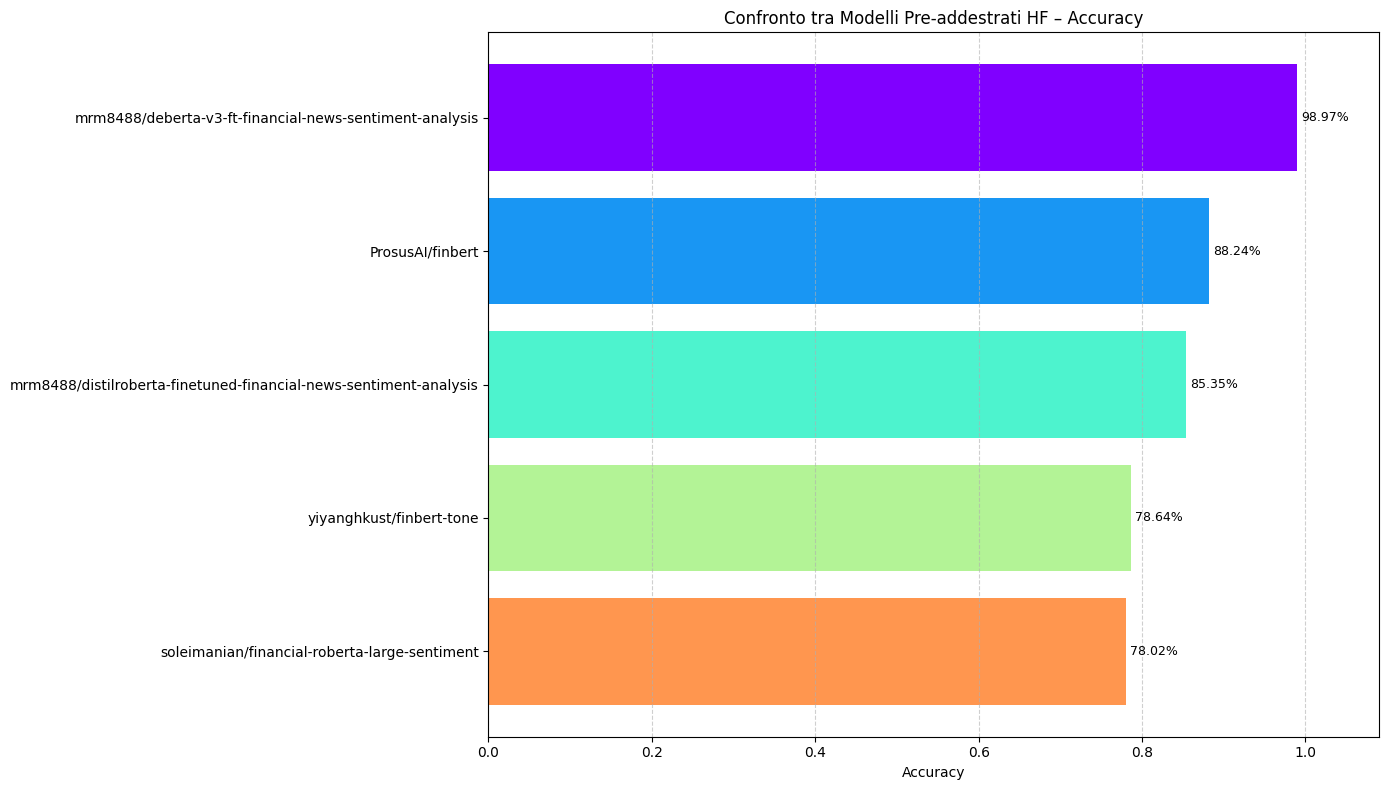

In [85]:
plot_results_summary(sorted_results, metric="accuracy")

Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



--- Test Results ---
              precision    recall  f1-score   support

    negative     0.9917    0.9917    0.9917       121
     neutral     0.9913    0.9913    0.9913       576
    positive     0.9853    0.9853    0.9853       272

    accuracy                         0.9897       969
   macro avg     0.9894    0.9894    0.9894       969
weighted avg     0.9897    0.9897    0.9897       969

Accuracy:  0.9897
Precision: 0.9894
Recall:    0.9894
F1 Score:  0.9894


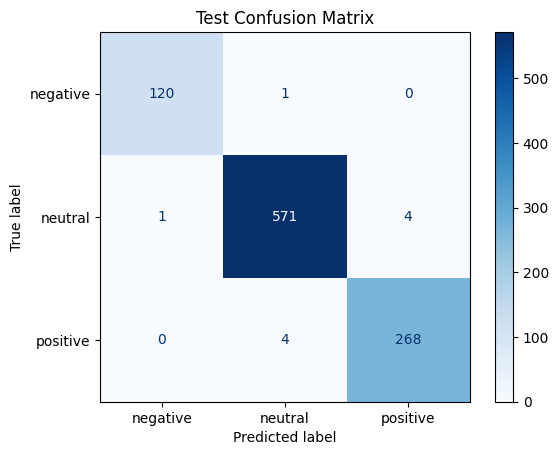

In [ ]:
best_model_row = sorted_results.iloc[0]
best_model = best_model_row["model"]
print(f"best model: {best_model}")

y_pred = evaluate_hf_model(X_test_raw, y_test, model_name=best_model)
evaluate_model_hf(y_test, y_pred, split_name="Test")

In [12]:
def check_errors(X_test_raw, y_test, y_pred):
    y_test_str =  label_encoder.inverse_transform(y_test)
    y_pred_str = label_encoder.inverse_transform(y_pred)

    errors_df = pd.DataFrame({
        "text": X_test_raw,
        "true_label": y_test_str,
        "predicted_label": y_pred_str
    })

    # Filtra solo gli errori
    misclassified = errors_df[errors_df["true_label"] != errors_df["predicted_label"]]
    print(misclassified.head(5))

In [ ]:
pd.set_option('display.max_colwidth', None)
check_errors(X_test_raw, y_test, y_pred)

# Fine-Tuning

### Verifico quanti layer ha ogni modello in modo da sbloccare solo gli ultimi N

In [ ]:
model_name = "mrm8488/deberta-v3-ft-financial-news-sentiment-analysis"
model = AutoModelForSequenceClassification.from_pretrained(model_name)

print("Numero totale layer:", len(model.base_model.encoder.layer))

for name, param in model.named_parameters():
    print(name)


In [ ]:
model_name = "ProsusAI/finbert"
model = AutoModelForSequenceClassification.from_pretrained(model_name)

print("Numero totale layer:", len(model.base_model.encoder.layer))

for name, param in model.named_parameters():
    print(name)

In [8]:
def load_and_freeze_model(model_name: str, n_last_layers_to_unfreeze: int = 2):
    """
    Carica un modello HuggingFace e sblocca solo gli ultimi N layer encoder + la classification head.

    Args:
        model_name (str): Nome del modello HuggingFace
        n_last_layers_to_unfreeze (int): Numero di layer finali da sbloccare

    Returns:
        model: il modello pronto per il fine-tuning
        tokenizer: il tokenizer corrispondente
    """

    # Carica modello e tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)

    # Congela tutto inizialmente
    for param in model.base_model.parameters():
        param.requires_grad = False

    # Tenta di accedere al blocco encoder
    try:
        encoder_layers = model.base_model.encoder.layer
    except AttributeError:
        raise ValueError(f"Impossibile accedere a encoder.layer per il modello: {model_name}")

    total_layers = len(encoder_layers)
    if n_last_layers_to_unfreeze > total_layers:
        raise ValueError(f"Richiesti {n_last_layers_to_unfreeze} layer da sbloccare, ma il modello ne ha solo {total_layers}.")

    # Costruisci la lista dei layer da sbloccare
    unfreeze_indices = list(range(total_layers - n_last_layers_to_unfreeze, total_layers))
    unfreeze_layer_names = [f"layer.{i}" for i in unfreeze_indices]

    # Sblocca solo i layer finali
    for name, param in model.base_model.named_parameters():
        if any(layer_name in name for layer_name in unfreeze_layer_names):
            param.requires_grad = True

    # Sblocca anche la classification head
    if hasattr(model, "classifier"):
        for param in model.classifier.parameters():
            param.requires_grad = True
    elif hasattr(model, "score"):
        for param in model.score.parameters():
            param.requires_grad = True
    else:
        raise ValueError("Nessuna classification head trovata (classifier o score).")

    print(f"[✓] Caricato {model_name} — totale layer encoder: {total_layers} — sbloccati ultimi {n_last_layers_to_unfreeze} layer.")

    return model, tokenizer


In [9]:
def compute_metrics(pred, is_binary=False):
    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids
    avg_type = 'binary' if is_binary else 'macro'
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, average=avg_type, zero_division=0),
        'recall': recall_score(labels, preds, average=avg_type, zero_division=0),
        'f1': f1_score(labels, preds, average=avg_type, zero_division=0),
    }

def plot_loss_curves(trainer):
    log_history = trainer.state.log_history

    epochs = []
    train_losses = []
    val_losses = []

    for entry in log_history:
        if "loss" in entry and "epoch" in entry:
            train_losses.append(entry["loss"])
            epochs.append(entry["epoch"])
        if "eval_loss" in entry:
            val_losses.append(entry["eval_loss"])

    plt.plot(epochs, train_losses, label="Training Loss")
    if val_losses:
        plt.plot(epochs, val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
def fine_tune_model(model_name: str, n_layers_to_unfreeze: int, train_df, val_df,):

    # Carica modello e tokenizer
    model, tokenizer = load_and_freeze_model(model_name, n_layers_to_unfreeze)

    # Conversione a Dataset Hugging Face
    train_dataset = Dataset.from_pandas(train_df)
    val_dataset = Dataset.from_pandas(val_df)

    # Tokenizzazione
    def tokenize_function(example):
        return tokenizer(example["text"], truncation=True)
    
    train_dataset = train_dataset.map(tokenize_function, batched=True)
    val_dataset = val_dataset.map(tokenize_function, batched=True)

    # TrainingArguments
    training_args = TrainingArguments(
        output_dir="./results",
        logging_dir="./logs", 
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=20,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        fp16=True
    )

    # Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    trainer.train()
    plot_loss_curves(trainer)

    print("[✓] Fine-tuning completato.")
    return trainer

def test_model(trainer, tokenizer, test_df):
    test_dataset = Dataset.from_pandas(test_df)

    def tokenize_function(example):
        return tokenizer(example["text"], truncation=True)
    
    test_dataset = test_dataset.map(tokenize_function, batched=True)

    # Predict
    results = trainer.predict(test_dataset)

    # Estrai etichette predette
    y_pred_ids = np.argmax(results.predictions, axis=1)
    y_pred_labels = label_encoder.inverse_transform(y_pred_ids)

    # Anche le label vere devono essere trasformate in stringhe
    y_true_labels = label_encoder.inverse_transform(test_df["label"])

    # Valutazione
    evaluate_model_hf(y_true_labels, y_pred_labels)
    
    return y_pred_ids

import torch

def get_cls_embeddings_from_df(model, tokenizer, df, batch_size=32, max_length=128):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    texts = df["text"].tolist()
    all_embeddings = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=max_length, return_tensors="pt")
            inputs = {k: v.to(device) for k, v in inputs.items()}

            # Estrai gli embedding dal backbone (escludendo la classification head)
            outputs = model.base_model(**inputs)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]  # CLS token
            all_embeddings.append(cls_embeddings.cpu())

    return torch.cat(all_embeddings, dim=0).numpy()

[✓] Caricato mrm8488/deberta-v3-ft-financial-news-sentiment-analysis — totale layer encoder: 6 — sbloccati ultimi 0 layer.


Map: 100%|██████████| 776/776 [00:00<00:00, 14059.95 examples/s]
C:\Users\mario\AppData\Local\Temp\ipykernel_18248\1142055341.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.072500,0.062360,0.983247,0.977985,0.987376,0.982588
2,0.062200,0.063095,0.981959,0.976512,0.986653,0.981477
3,0.064900,0.060040,0.984536,0.981258,0.988099,0.984631
4,0.067600,0.061957,0.984536,0.981258,0.988099,0.984631
5,0.065200,0.063592,0.984536,0.981258,0.988099,0.984631
6,0.069800,0.063785,0.983247,0.977985,0.987376,0.982588


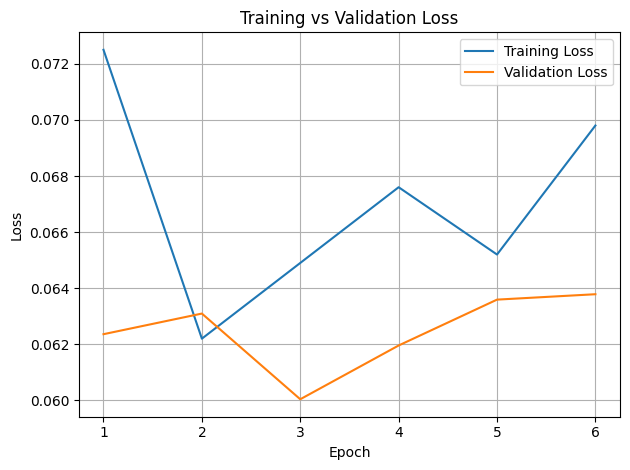

[✓] Fine-tuning completato.


In [10]:

model_name = "mrm8488/deberta-v3-ft-financial-news-sentiment-analysis"
n_layers = 0

trainer = fine_tune_model(
    model_name=model_name,
    n_layers_to_unfreeze=n_layers,
    train_df=train_df,
    val_df=val_df
)

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Map: 100%|██████████| 969/969 [00:00<00:00, 9317.62 examples/s]



--- Test Results ---
              precision    recall  f1-score   support

    negative     0.9917    0.9917    0.9917       121
     neutral     0.9896    0.9931    0.9913       576
    positive     0.9889    0.9816    0.9852       272

    accuracy                         0.9897       969
   macro avg     0.9901    0.9888    0.9894       969
weighted avg     0.9897    0.9897    0.9897       969

Accuracy:  0.9897
Precision: 0.9901
Recall:    0.9888
F1 Score:  0.9894


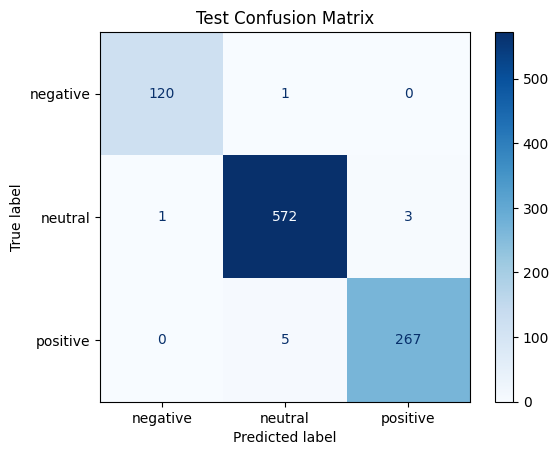

                                                   text true_label  \
1122  ` For Nordea , moving into the new headquarter...   positive   
1874  This bold spinning 360 red fabric design is se...   positive   
4124  Outokumpu 's steel mill in Tornio , in Finland...   negative   
2250  Under the agreement Ponsse will provide forest...    neutral   
3571  Earnings per share EPS in 2005 amounted to a l...    neutral   

     predicted_label  
1122         neutral  
1874         neutral  
4124         neutral  
2250        positive  
3571        negative  


In [16]:
y_pred_ids = test_model(trainer, trainer.tokenizer, test_df)
check_errors(X_test_raw, y_test, y_pred_ids)

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
C:\Users\mario\AppData\Local\Temp\ipykernel_18248\3425048325.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(classes))
C:\Users\mario\AppData\Local\Temp\ipykernel_18248\3425048325.py:19: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_2d[errors, 0], X_2d[errors, 1],


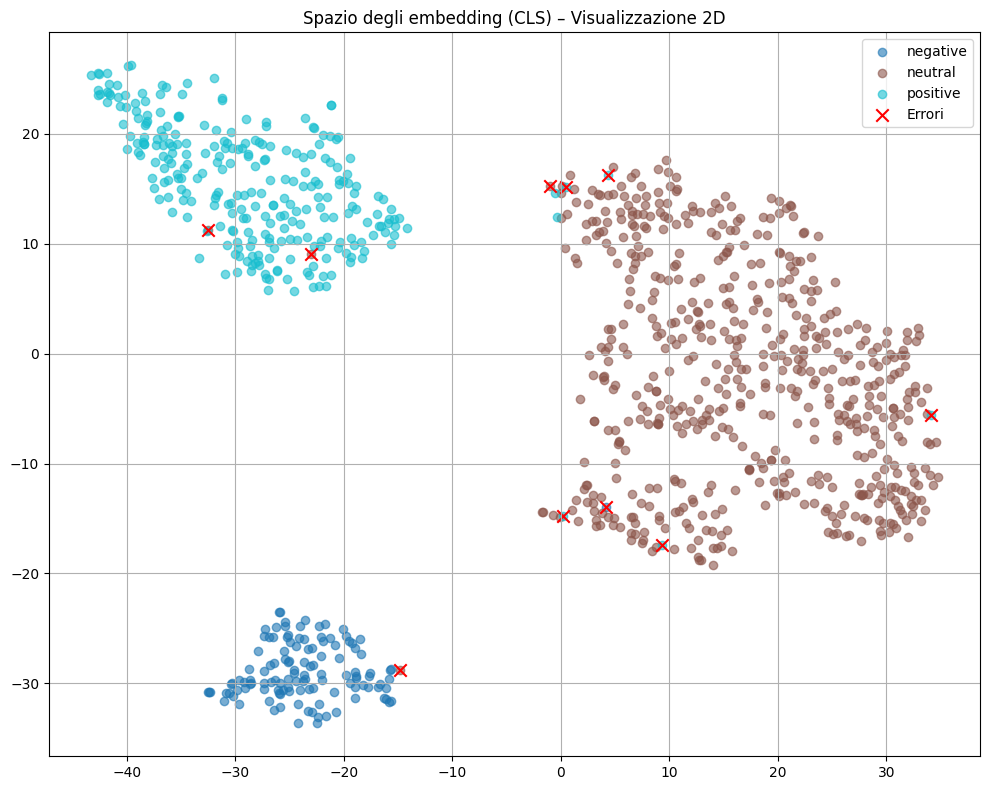

In [15]:
def plot_embedding_space(X_2d, y_true, y_pred, class_names=None):
    plt.figure(figsize=(10, 8))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    errors = y_true != y_pred

    classes = np.unique(y_true)
    colors = plt.cm.get_cmap("tab10", len(classes))

    for i, cls in enumerate(classes):
        idx = y_true == cls
        plt.scatter(X_2d[idx, 0], X_2d[idx, 1],
                    c=[colors(i)],
                    label=class_names[cls] if class_names is not None else f"Class {cls}",
                    alpha=0.6)

    # Evidenzia gli errori
    plt.scatter(X_2d[errors, 0], X_2d[errors, 1],
                c="red", edgecolors="black", marker="x", s=80, label="Errori")

    plt.legend()
    plt.title("Spazio degli embedding (CLS) – Visualizzazione 2D")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

cls_embeddings = get_cls_embeddings_from_df(
    model=trainer.model,
    tokenizer=trainer.tokenizer,
    df=test_df
)

# Usa t-SNE per visualizzazione non lineare (più "naturale")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_2d = tsne.fit_transform(cls_embeddings)

y_true = test_df["label"].tolist()  # ID numerici
y_pred = y_pred_ids  # da trainer.predict()

plot_embedding_space(X_2d, y_true, y_pred, class_names=label_encoder.classes_)


[✓] Caricato ProsusAI/finbert — totale layer encoder: 12 — sbloccati ultimi 0 layer.


Map: 100%|██████████| 776/776 [00:00<00:00, 15520.24 examples/s]
C:\Users\mario\AppData\Local\Temp\ipykernel_12332\434502847.py:71: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.436400,1.558505,0.149485,0.147255,0.152169,0.118777
2,0.873500,0.476963,0.869845,0.843208,0.896182,0.863998
3,0.367300,0.297235,0.895619,0.870695,0.910133,0.888345
4,0.301400,0.278524,0.896907,0.871903,0.910856,0.889383
5,0.299000,0.277271,0.895619,0.872095,0.910133,0.889153
6,0.290100,0.274652,0.900773,0.879838,0.913025,0.894953
7,0.293100,0.272011,0.904639,0.883519,0.915195,0.898072
8,0.292900,0.270301,0.904639,0.883519,0.915195,0.898072
9,0.293800,0.270232,0.904639,0.883519,0.915195,0.898072
10,0.286000,0.269642,0.905928,0.886261,0.915918,0.899953


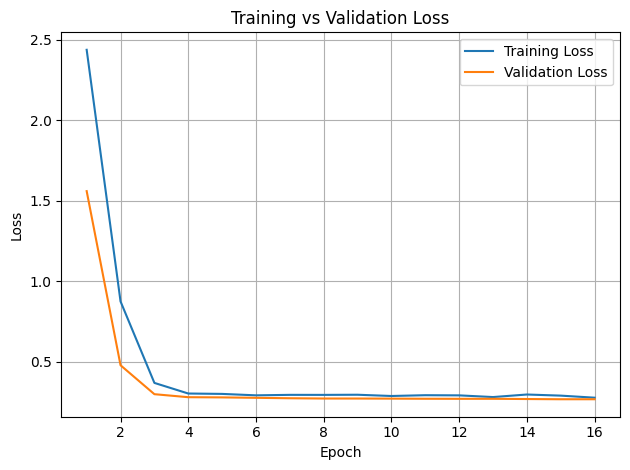

[✓] Fine-tuning completato.


In [ ]:
model_name = "ProsusAI/finbert"
n_layers = 0

trainer = fine_tune_model(
    model_name=model_name,
    n_layers_to_unfreeze=n_layers,
    train_df=train_df,
    val_df=val_df
)

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Map: 100%|██████████| 969/969 [00:00<00:00, 15380.73 examples/s]



--- Test Results ---
              precision    recall  f1-score   support

    negative     0.8394    0.9504    0.8915       121
     neutral     0.9466    0.8924    0.9187       576
    positive     0.8374    0.8897    0.8627       272

    accuracy                         0.8989       969
   macro avg     0.8745    0.9108    0.8910       969
weighted avg     0.9026    0.8989    0.8996       969

Accuracy:  0.8989
Precision: 0.8745
Recall:    0.9108
F1 Score:  0.8910


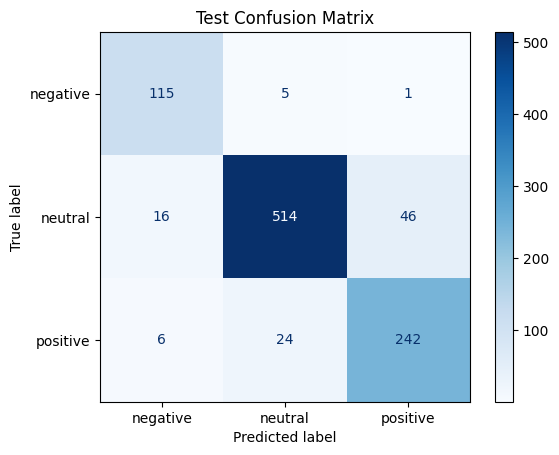

                                                                                                                                                                 text  \
1012  A maximum of 20 employees , who work in Karttakeskus and are responsible for producing Geographic Information Services , will be affected , the company added .   
1861                                                                                So far the company has awarded more than $ 350,000 worth of tools and materials .   
511                                                            The company plans to spend the proceeds from the rights offering for strengthening its balance sheet .   
4022                                                                                         He said : `` It is for sale again and we will be actively marketing it .   
1834                                                      After the renovation the biggest moulding line in the Orhangazi foundry is the most modern line i

In [78]:
y_pred = test_model(trainer, trainer.tokenizer, test_df)

check_errors(X_test_raw, y_test, y_pred)